# HTT Magspec analysis 

In [1]:
# define paths to find configs and set up logging
from geecs_data_utils.scan_data import ScanPaths
from geecs_data_utils.config_roots import image_analysis_config

import logging

logging.getLogger("image_analysis").setLevel(logging.WARNING)
logging.getLogger("geecs_data_utils").setLevel(logging.WARNING)


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)


image_analysis_config.set_base_dir(ScanPaths.paths_config.image_analysis_configs_path)

PosixPath('/Users/samuelbarber/Desktop/Github_repos/GEECS-Plugins-Configs/image_analysis_configs')

This first section illustrates how to simply work directly with the algorithm starting with a preloaded image. We use a predefined config for "U_FROG_Grenouille-Temporal" to instantiate a BeamAnalyzer. Note, config can be used to implement various background subtractions, filtering, thresholding etc. It can use used a simple preprocessing step.

Here, we use the BeamAnalyzer to execute it's basic prepocessing and then store the image as gr_trace. The result is visualized for inspection

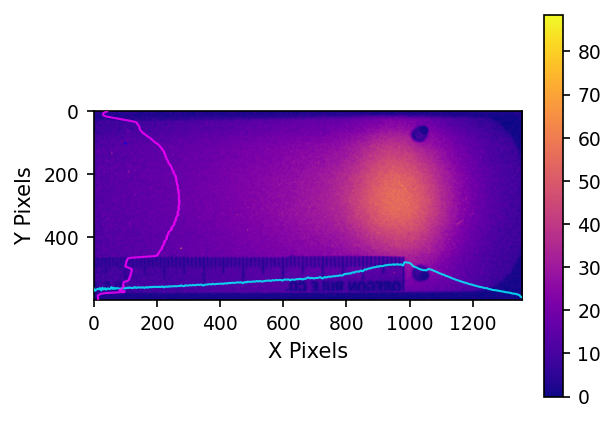

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='X Pixels', ylabel='Y Pixels'>)

In [2]:
from pathlib import Path
import numpy as np

from image_analysis.offline_analyzers.magspec_manual_calib_analyzer import (
    MagSpecManualCalibAnalyzer,
)
from image_analysis.offline_analyzers.beam_analyzer import BeamAnalyzer

file_path = Path(
    "/Users/samuelbarber/Desktop/Github_repos/GEECS-Plugins/ImageAnalysis/image_analysis/magspec_code/example_data/raw_data/HTT-C23_1_MagSpec1/Scan007_HTT-C23_1_MagSpec1_156.png"
)
# file_path = Path(
#     '/Users/samuelbarber/Desktop/Github_repos/GEECS-Plugins/ImageAnalysis/magspec_code/example_data/raw_data/HTT-C23_4_MagSpec4/Scan007_HTT-C23_4_MagSpec4_001.png'
# )

analyzer = BeamAnalyzer(camera_config_name="HTT-MagCam1")
res = analyzer.analyze_image_file(file_path)
gr_trace = res.processed_image

analyzer.visualize(res)

With a loaded image, we can directly apply the retrieval algorithm. We start by importing the FrogDllRetrieval object. We instanatiate a retrieval object using a class method (.from-config()) that finds the paths to the proper dll file and the 32-bit python executable. Then, the retrieval is executed on the gr_trace and using the hardware specific calibration factors, and user defined parameters (e.g. grid size, target_error and max_time_seconds). Attributes that are generated by this retrieval are shown in comments.

In [3]:
from image_analysis.offline_analyzers.magspec_manual_calib_analyzer import (
    DnnAxisCalibration,
)
from pathlib import Path

camera_calibration_file = Path(
    "/Users/samuelbarber/Desktop/Github_repos/GEECS-Plugins/ImageAnalysis/image_analysis/magspec_code/calibrations/260224DnnVarianCam.txt"
)
trajectory_calibration_file = Path(
    "/Users/samuelbarber/Desktop/Github_repos/GEECS-Plugins/ImageAnalysis/image_analysis/magspec_code/calibrations/170925DnnVarianTrj.txt"
)

# Build calibration object from files
dnn_cal = DnnAxisCalibration.from_dnn_calibration_files(
    camera_calibration_file=str(camera_calibration_file),
    trajectory_calibration_file=str(trajectory_calibration_file),
    camera_number=1,
    magnetic_field_t=0.2003,
)

# Build pixel->energy axis
image_width = dnn_cal.x_end_px - dnn_cal.x_start_px + 1
energy_axis = dnn_cal.build_axis(image_width=image_width)

print(f"axis length: {len(energy_axis)}")
print(f"energy min/max: {energy_axis.min():.3f}, {energy_axis.max():.3f} MeV")
print(f"first/last: {energy_axis[0]:.3f}, {energy_axis[-1]:.3f} MeV")
energy_axis[:10]  # quick peek

axis length: 1357
energy min/max: 75.059, 202.144 MeV
first/last: 75.059, 202.144 MeV


array([75.05938888, 75.09286368, 75.12640064, 75.1600003 , 75.19366098,
       75.22738083, 75.26115803, 75.29499076, 75.32887719, 75.36281548])

Next, we can visualize the results comparing the initial trace to the retrieved trace. We define and use a color scale commonly used by labview apps at BELLA

In [6]:
analyzer = MagSpecManualCalibAnalyzer(camera_config_name="HTT-MagCam1")

pixel_to_energy = analyzer.magspec_config.calibration.build_axis(
    image_width=res.processed_image.shape[1]
)

2026-03-06 16:37:25,846 - image_analysis.algorithms.axis_interpolation - WARNING - Requested physical_min (10.000) below calibration range (75.134). Clipping to calibration minimum.
2026-03-06 16:37:25,846 - image_analysis.algorithms.axis_interpolation - WARNING - Requested physical_max (520.000) above calibration range (202.346). Clipping to calibration maximum.


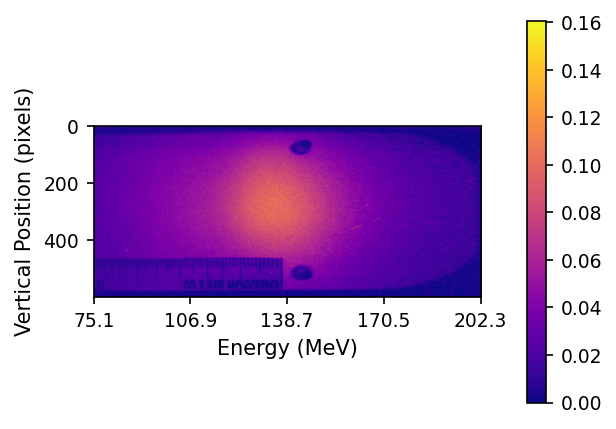

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='Energy (MeV)', ylabel='Vertical Position (pixels)'>)

In [8]:
res_yes = analyzer.analyze_image_file(image_filepath=file_path)
analyzer.visualize(res_yes)

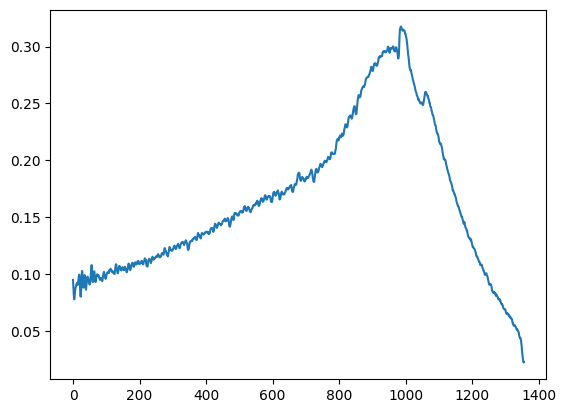

In [28]:
from matplotlib import pyplot as plt

energy_axis = analyzer.magspec_config.calibration.build_axis(
    image_width=res.processed_image.shape[1]
)
plt.plot(
    np.sum(res.processed_image, axis=0)
    * analyzer.magspec_config.charge_calibration.factor_fc_per_count
    / 0.125
    / 1e3
)

array([ 75.13433585,  75.16784407,  75.20141452, ..., 201.83267154,
       202.08838062, 202.3457883 ], shape=(1357,))

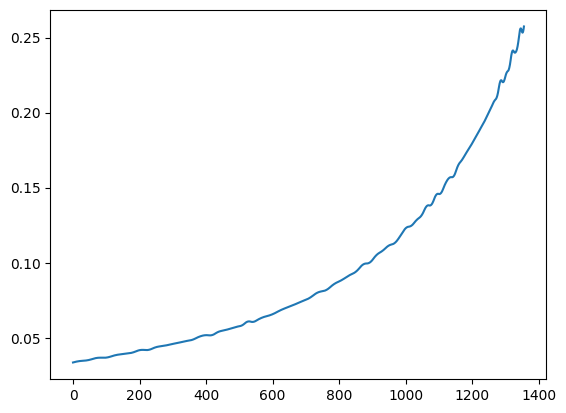

In [24]:
plt.plot(np.diff(energy_axis))
energy_axis